In [23]:
import math
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
import re
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
from nltk.corpus import stopwords
from nltk import probability
import numpy as np
from scipy.spatial import distance_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.sparse import hstack, csr_matrix
from sklearn.naive_bayes import MultinomialNB, ComplementNB, GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

# Importing stemmers and a lemmatizer from NLTK
from nltk.stem.porter import PorterStemmer       # oldest, simplest English stemmer
from nltk.stem.snowball import SnowballStemmer    # improved version of Porter (a.k.a. Porter2)
from nltk.stem.wordnet import WordNetLemmatizer   # dictionary-based lemmatizer using WordNet

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [24]:
news_data = pd.read_csv("data.csv", on_bad_lines='skip', engine='python')
news_validation_data = pd.read_csv("validation_data.csv", on_bad_lines='skip', engine='python')
print(f"Shape: {news_data.shape}")
print(news_data.info())

Shape: (74564, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74564 entries, 0 to 74563
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    74564 non-null  object
 1   title    74564 non-null  object
 2   text     74563 non-null  object
 3   subject  74563 non-null  object
 4   date     74563 non-null  object
dtypes: object(5)
memory usage: 2.8+ MB
None


In [25]:
news_data.head()

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


# **1. Exploratory Data Analysis**

**Content**  
1.1 Class Balance Fake vs. Real  
1.2 Text length title vs. full text  
1.3 Subject / data distribution  
1.4 Top words per class  


#### **1.0 Dataset Overview & Data Quality**

In [26]:
print('=== Column dtypes ===')
print(news_data.dtypes)

print('\n=== Missing values ===')
print(news_data.isnull().sum())

print('\n=== Duplicate rows ===')
n_dup = news_data.duplicated(subset=['title', 'text']).sum()
print(f'{n_dup} duplicate rows (title + text match)')

# Inspect empty / very short texts
short_titles = news_data[news_data['title'].str.len() < 10]
short_texts  = news_data[news_data['text'].str.len() < 20]
print(f'\nTitles shorter than 10 chars: {len(short_titles)}')
print(f'Texts shorter than 20 chars:  {len(short_texts)}')

=== Column dtypes ===
label      object
title      object
text       object
subject    object
date       object
dtype: object

=== Missing values ===
label      0
title      0
text       1
subject    1
date       1
dtype: int64

=== Duplicate rows ===
38051 duplicate rows (title + text match)

Titles shorter than 10 chars: 2
Texts shorter than 20 chars:  1294


In [27]:
# SHOW DUPLICATE ROWS

duplicates = news_data[news_data.duplicated(subset=['title', 'text'], keep=False)]
print(duplicates[['title', 'text']].head())


                                                 title  \
406  Trump baffles Sweden with crime comment, says ...   
407  Emails show ties between new EPA head, energy ...   
408  U.S. to discuss immigration efforts with Mexic...   
409  Trump issues first public condemnation of anti...   
410  Trump to spare U.S. 'dreamer' immigrants from ...   

                                                  text  
406   (This story corrects paragraph 8 to clarify S...  
407  WASHINGTON (Reuters) - Emails released by the ...  
408  WASHINGTON (Reuters) - U.S. Secretary of State...  
409  WASHINGTON (Reuters) - U.S. President Donald T...  
410  WASHINGTON (Reuters) - President Donald Trump’...  


In [28]:
# REMOVE DUPLICATES

print("Shape before removing duplicates:", news_data.shape)
news_data = news_data.drop_duplicates(subset=['title', 'text'])

print("Shape after removing duplicates:", news_data.shape)

Shape before removing duplicates: (74564, 5)
Shape after removing duplicates: (36513, 5)


In [29]:
# VALIDATE DUPLICATES REMOVED

remaining_duplicates = news_data.duplicated(subset=['title', 'text']).sum()

print("Remaining duplicate rows:", remaining_duplicates)

Remaining duplicate rows: 0


#### **1.1 Class Balance Fake vs. Real**

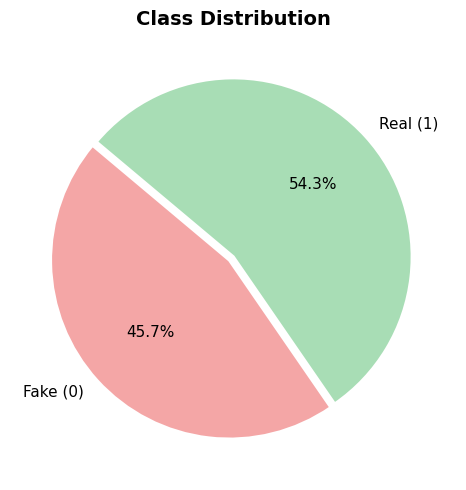


Conclusion: Dataset is considered reasonably balanced. → no resampling required.


In [31]:
news_data['label'] = pd.to_numeric(news_data['label'], errors='coerce')
label_counts = news_data['label'].value_counts().sort_index()
label_pct = label_counts / len(news_data) * 100

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    label_counts.values,
    labels=['Fake (0)', 'Real (1)'],
    colors=['#f4a6a6', '#a8ddb5'],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.03, 0],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)

ax.set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nConclusion: Dataset is considered reasonably balanced. → no resampling required.')

#### **1.2 Text length title vs. full text**

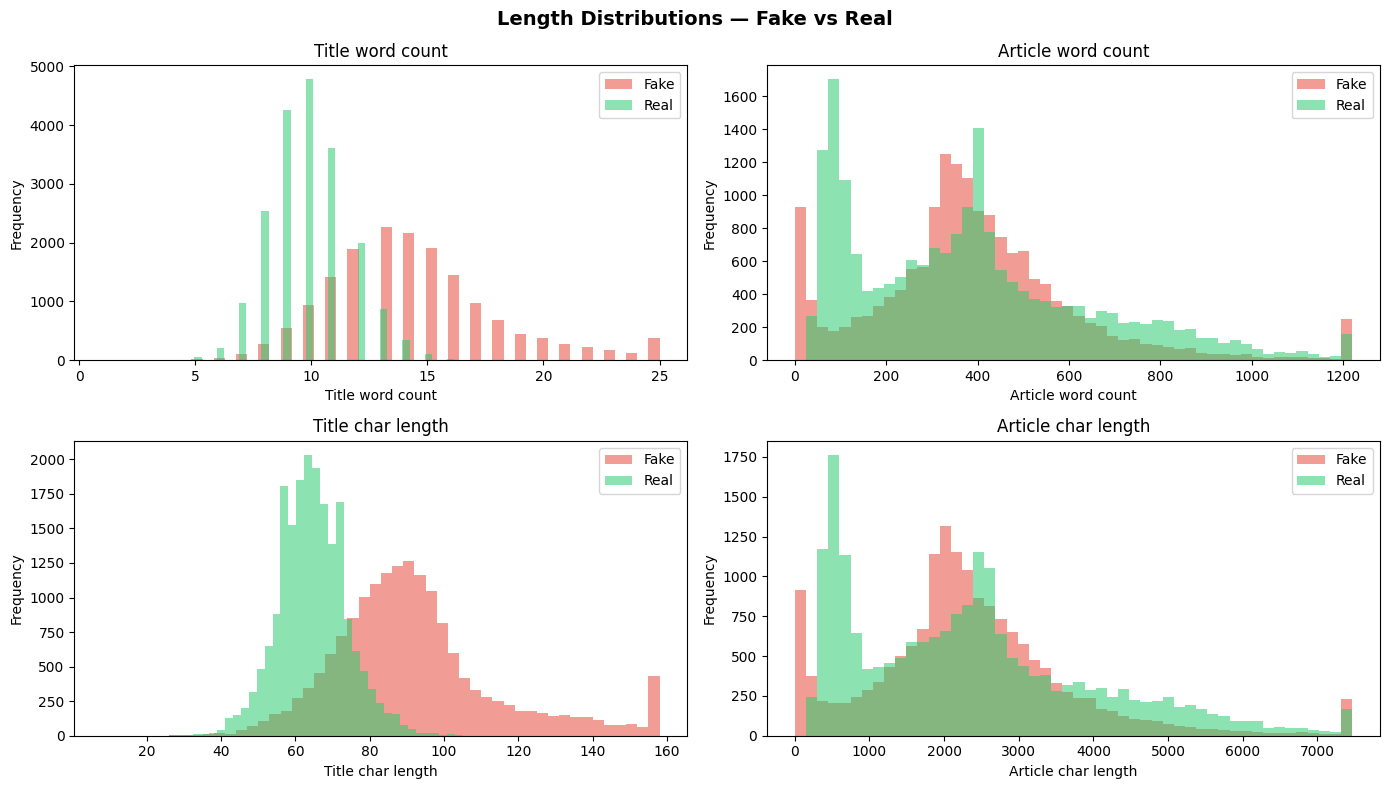

Title word counts by class:
         count  mean  std  min   25%   50%   75%   max
label                                                 
0.0    16690.0  14.4  3.9  1.0  12.0  14.0  16.0  42.0
1.0    19822.0   9.9  1.7  4.0   9.0  10.0  11.0  20.0
       title_char_len  text_char_len  title_word_count  text_word_count
label                                                                  
0.0           91.9549      2390.6114           14.4271         399.9507
1.0           64.6189      2388.2548            9.9463         386.0187

→ Fake news consistently occupies longer length ranges than real news — both in titles and body text.
  That could serve as a useful feature signal in a fake news classification model.


In [32]:
news_data = news_data.copy()

news_data.loc[:, 'title_char_len']  = news_data['title'].astype(str).str.len()
news_data.loc[:, 'text_char_len']   = news_data['text'].astype(str).str.len()
news_data.loc[:, 'title_word_count'] = news_data['title'].astype(str).str.split().str.len()
news_data.loc[:, 'text_word_count']  = news_data['text'].astype(str).str.split().str.len()

means = news_data.groupby('label')[
    ['title_char_len', 'text_char_len', 'title_word_count', 'text_word_count']
].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, label_str, ax in [
    ('title_word_count', 'Title word count', axes[0, 0]),
    ('text_word_count',  'Article word count', axes[0, 1]),
    ('title_char_len',   'Title char length', axes[1, 0]),
    ('text_char_len',    'Article char length', axes[1, 1]),
]:
    upper_limit = news_data[col].quantile(0.99)

    for lbl, color, name in [(0, '#e74c3c', 'Fake'), (1, '#2ecc71', 'Real')]:
        ax.hist(
            news_data.loc[news_data['label'] == lbl, col].clip(upper=upper_limit),
            bins=50,
            alpha=0.55,
            color=color,
            label=name,
            edgecolor='none'
        )

    ax.set_title(label_str)
    ax.set_xlabel(label_str)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Length Distributions — Fake vs Real', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Title word counts by class:')
print(news_data.groupby('label')['title_word_count'].describe().round(1))

print(means.round(4))

print('\n→ Fake news consistently occupies longer length ranges than real news — both in titles and body text.')
print('  That could serve as a useful feature signal in a fake news classification model.')

#### **1.3 Subject / data distribution**

<Figure size 1400x600 with 0 Axes>

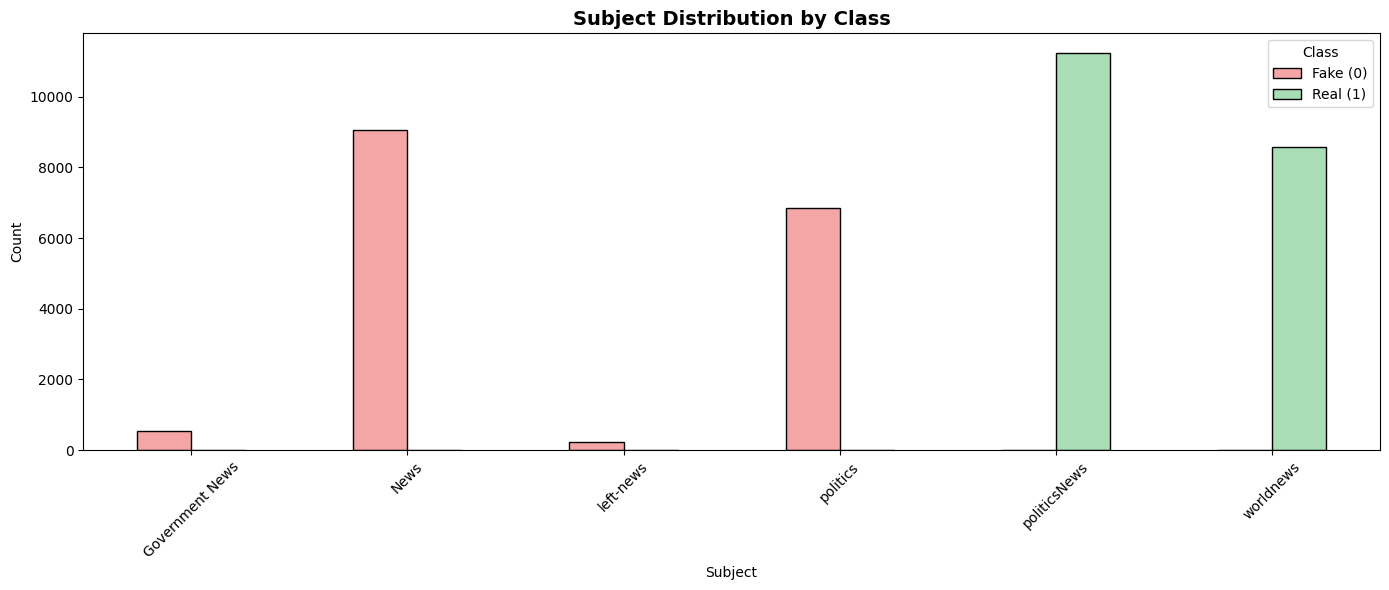

                 Fake (0)  Real (1)
subject                            
Government News       535         0
News                 9061        12
left-news             230         0
politics             6851         0
politicsNews            0     11231
worldnews              13      8579


In [33]:
plt.figure(figsize=(14, 6))

# Count Fake/Real articles per subject
subject_label_counts = (
    news_data.groupby(['subject', 'label'])
      .size()
      .unstack(fill_value=0)
)

# Rename labels for clarity
subject_label_counts.columns = ['Fake (0)', 'Real (1)']

# Plot
subject_label_counts.plot(
    kind='bar',
    stacked=False,
    figsize=(14, 6),
    color=['#f4a6a6', '#a8ddb5'],
    edgecolor='black'
)

plt.title("Subject Distribution by Class", fontsize=14, fontweight='bold')
plt.xlabel("Subject")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.legend(title='Class')

plt.tight_layout()
plt.show()

# Print exact counts
print(subject_label_counts)

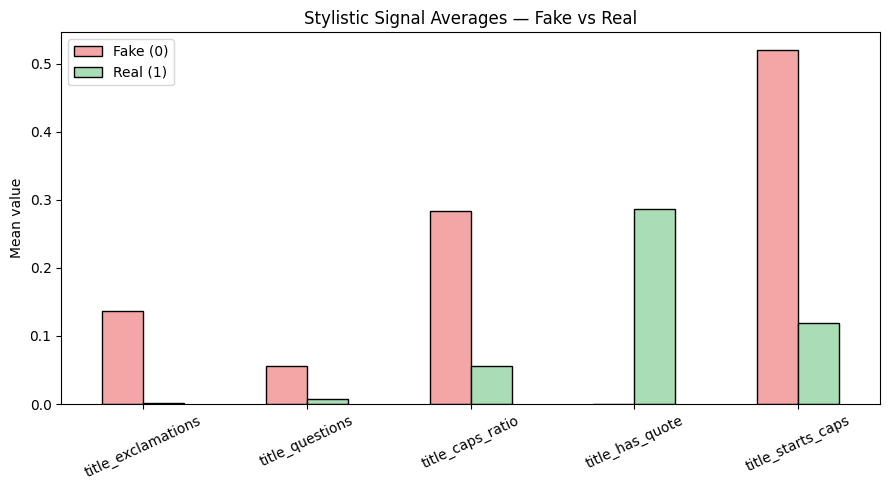

                    Fake (0)  Real (1)
title_exclamations    0.1364    0.0008
title_questions       0.0562    0.0069
title_caps_ratio      0.2843    0.0554
title_has_quote       0.0005    0.2873
title_starts_caps     0.5203    0.1187

→ Fake articles show ~200× more exclamation marks and ~5× higher caps ratio.
  These will be strong engineered features.


In [34]:
news_data['title_exclamations'] = news_data['title'].str.count('!')
news_data['title_questions']    = news_data['title'].str.count(r'\?')
news_data['title_caps_ratio']   = news_data['title'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)
news_data['title_has_quote']    = news_data['title'].str.contains(r'["\']').astype(int)
news_data['title_starts_caps']  = news_data['title'].apply(
    lambda x: 1 if len(x) > 0 and x.split()[0].isupper() else 0
)

style_features = ['title_exclamations', 'title_questions',
                   'title_caps_ratio', 'title_has_quote', 'title_starts_caps']

means = news_data.groupby('label')[style_features].mean().T
means.columns = ['Fake (0)', 'Real (1)']

fig, ax = plt.subplots(figsize=(9, 5))
means.plot(kind='bar', ax=ax, color=['#f4a6a6', '#a8ddb5'], edgecolor='black')
ax.set_title('Stylistic Signal Averages — Fake vs Real')
ax.set_ylabel('Mean value')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

print(means.round(4))
print('\n→ Fake articles show ~200× more exclamation marks and ~5× higher caps ratio.')
print('  These will be strong engineered features.')

#### **1.4 Top words per class**

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


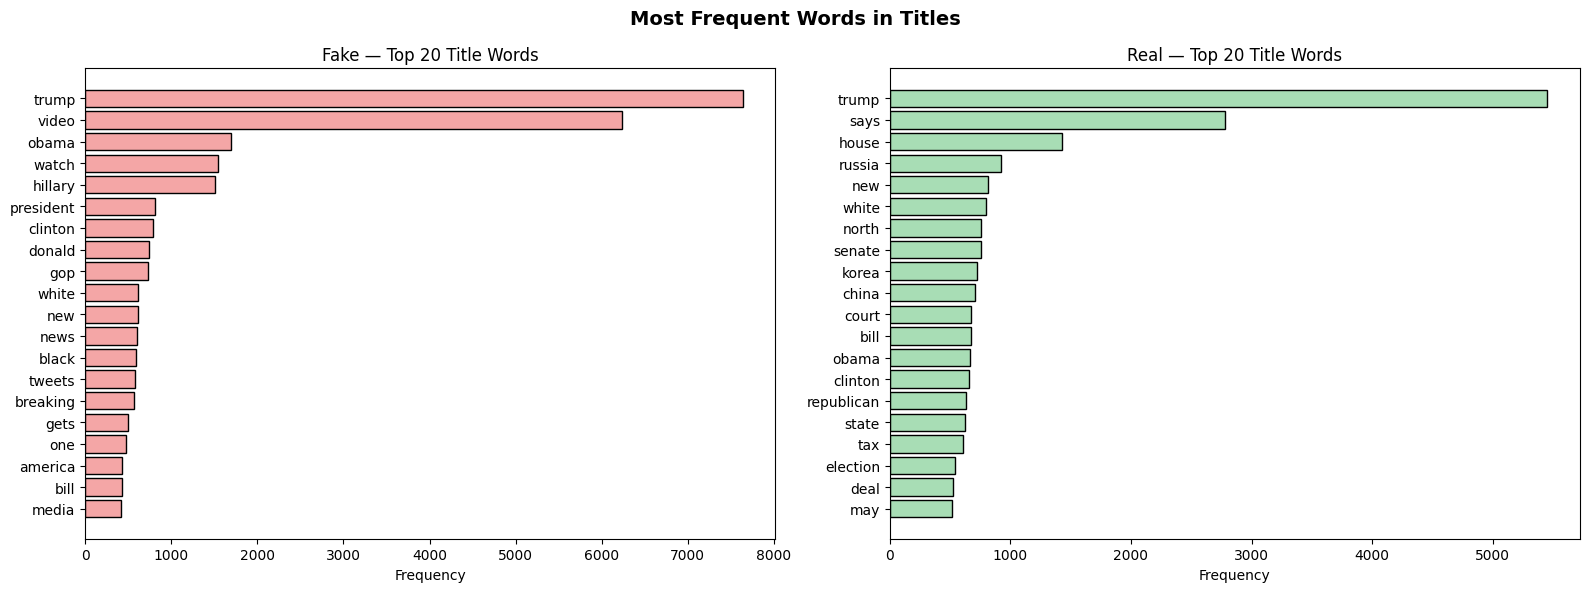

In [35]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=30):
    """Tokenize, lowercase, remove stopwords, return top-n word frequencies."""
    all_words = []
    for text in texts:
        tokens = re.findall(r'[a-z]+', text.lower())
        all_words.extend([w for w in tokens if w not in stop_words and len(w) > 2])
    return Counter(all_words).most_common(n)

fake_titles = news_data.loc[news_data['label'] == 0, 'title']
real_titles = news_data.loc[news_data['label'] == 1, 'title']

top_fake = get_top_words(fake_titles)
top_real = get_top_words(real_titles)

# --- Bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, top, title, color in [
    (axes[0], top_fake[:20], 'Fake — Top 20 Title Words', '#f4a6a6'),
    (axes[1], top_real[:20], 'Real — Top 20 Title Words', '#a8ddb5'),
]:
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words in Titles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

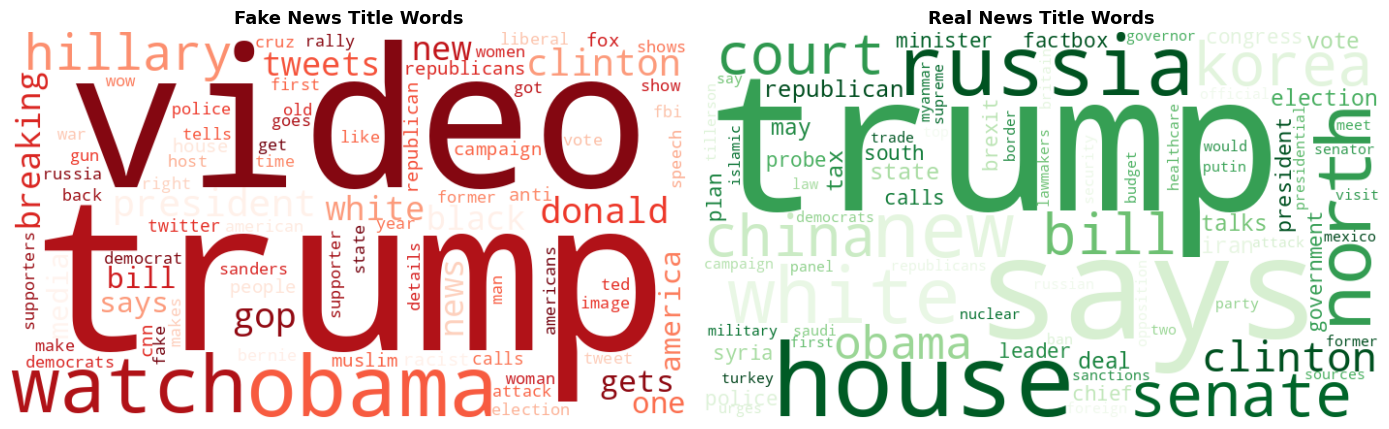

In [36]:
def make_wordcloud(top_words_list, colormap, title):
    freq_dict = dict(top_words_list)
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=colormap, max_words=80)
    wc.generate_from_frequencies(freq_dict)
    return wc

fake_wc = make_wordcloud(get_top_words(fake_titles, 100), 'Reds', 'Fake')
real_wc = make_wordcloud(get_top_words(real_titles, 100), 'Greens', 'Real')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, wc, title in [
    (axes[0], fake_wc, 'Fake News Title Words'),
    (axes[1], real_wc, 'Real News Title Words'),
]:
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

________________________________________________________________________________________________

#### **Feature Engineering**

Based on the EDA we engineer the following feature groups:

| Group | Features | Rationale from EDA |
|-------|----------|--------------------|
| **Length** | `title_word_count`, `text_word_count`, `title_char_len`, `text_char_len` | Fake titles are ~50% longer in word count |
| **Style** | `title_exclamations`, `title_questions`, `title_caps_ratio`, `title_has_quote`, `title_starts_caps` | Fake titles use far more punctuation & caps |

In [37]:
# Reload a clean copy so feature engineering is self-contained
# df = pd.read_csv('data.csv', on_bad_lines='skip')

# Length Features

news_data['title_char_len']   = news_data['title'].str.len()
news_data['text_char_len']    = news_data['text'].str.len()
news_data['title_word_count'] = news_data['title'].str.split().str.len()
news_data['text_word_count']  = news_data['text'].str.split().str.len()

print('Length features added.')

# Stylistic / Punctuation Features

news_data['title_exclamations'] = news_data['title'].str.count('!')
news_data['title_questions']    = news_data['title'].str.count(r'\?')

news_data['title_caps_ratio'] = news_data['title'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)

news_data['title_has_quote'] = news_data['title'].str.contains(r'["\']').astype(int)

news_data['title_starts_caps'] = news_data['title'].apply(
    lambda x: int(x.split()[0].isupper()) if x.strip() else 0
)

Length features added.


In [38]:
# Summary of engineered numeric features

NUMERIC_FEATURES = news_data.columns[7:].tolist()

print(f'{len(NUMERIC_FEATURES)} numeric features ready.')
print(news_data[NUMERIC_FEATURES].describe().round(3))

7 numeric features ready.
       title_word_count  text_word_count  title_exclamations  title_questions  \
count         36513.000        36512.000           36513.000        36513.000   
mean             11.994          392.387               0.063            0.029   
std               3.681          277.766               0.268            0.179   
min               1.000            0.000               0.000            0.000   
25%              10.000          212.000               0.000            0.000   
50%              11.000          367.000               0.000            0.000   
75%              14.000          507.000               0.000            0.000   
max              42.000         7033.000               4.000            3.000   

       title_caps_ratio  title_has_quote  title_starts_caps  
count         36513.000        36513.000          36513.000  
mean              0.160            0.156              0.302  
std               0.147            0.363              0.45

In [39]:
news_data.head()

,label,title,text,subject,date,title_char_len,text_char_len,title_word_count,text_word_count,title_exclamations,title_questions,title_caps_ratio,title_has_quote,title_starts_caps
0,1.0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",64,4659.0,10,749.0,0,0,0.062500,0,0
1,1.0,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",64,4077.0,9,624.0,0,0,0.062500,0,1
2,1.0,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",60,2789.0,10,457.0,0,0,0.116667,1,0
3,1.0,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",59,2461.0,9,376.0,0,0,0.135593,0,1
4,1.0,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",69,5204.0,11,852.0,0,0,0.057971,1,0


# **2. Text Processing**

**Content**  
2.1. Tokenization and lowercase + punctuation removal  
2.2. Stop word removal NTLK    
2.3. Lemmatisation   
2.4. Stemming  
2.5. Rejoin tokenized tokens into a plain string



#### **2.1. Tokenization**


We tokenize the title mainly as headlines are written to be punchy and distinctive (fake news titles tend to have very different vocabulary and tone from real ones)

The text column is much longer and noisier — it adds computation time and can actually introduce more irrelevant vocabulary that dilutes the signal.

FInally, the fucntion created also helps us remove capital letters and punctuation marks within the tokenization step. As a consequence, all tokens are lowercased with `.lower()`
and non-alphabetic tokens (punctuation, numbers, symbols) are discarded using `.isalpha()`.

In [40]:
from nltk.tokenize import word_tokenize

def tokenize_and_clean_Title(row):
    """Tokenize, lowercase, and keep only alphabetic words."""
    tokens = word_tokenize(row['title'])
    return [w.lower() for w in tokens if w.isalpha()]


news_data['Tokenized_Title'] = news_data.apply(tokenize_and_clean_Title, axis=1)
news_data[['title', 'Tokenized_Title']].head()

,title,Tokenized_Title
0,"As U.S. budget fight looms, Republicans flip t...","[as, budget, fight, looms, republicans, flip, ..."
1,U.S. military to accept transgender recruits o...,"[military, to, accept, transgender, recruits, ..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,"[senior, republican, senator, mueller, do, his..."
3,FBI Russia probe helped by Australian diplomat...,"[fbi, russia, probe, helped, by, australian, d..."
4,Trump wants Postal Service to charge 'much mor...,"[trump, wants, postal, service, to, charge, mo..."


### **2.2. Stopword removal**

Common English stop words (e.g. "the", "is", "in") are removed using NLTK's built-in
stop word list. These words appear in almost every document and carry little
discriminative value for fake vs. real news classification.
The result is stored in `Title_no_stopwords`.

In [41]:
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(token_list):
    """Remove common English stop words from a list of tokens."""
    return [w for w in token_list if w not in stop_words]


news_data['Title_no_stopwords'] = news_data['Tokenized_Title'].apply(remove_stopwords)
news_data[['title', 'Tokenized_Title', 'Title_no_stopwords']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,title,Tokenized_Title,Title_no_stopwords
0,"As U.S. budget fight looms, Republicans flip t...","[as, budget, fight, looms, republicans, flip, ...","[budget, fight, looms, republicans, flip, fisc..."
1,U.S. military to accept transgender recruits o...,"[military, to, accept, transgender, recruits, ...","[military, accept, transgender, recruits, mond..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,"[senior, republican, senator, mueller, do, his...","[senior, republican, senator, mueller, job]"
3,FBI Russia probe helped by Australian diplomat...,"[fbi, russia, probe, helped, by, australian, d...","[fbi, russia, probe, helped, australian, diplo..."
4,Trump wants Postal Service to charge 'much mor...,"[trump, wants, postal, service, to, charge, mo...","[trump, wants, postal, service, charge, amazon..."


#### **2.3. Lemmatisation**  

The final preprocessing steps involes reducing each word to its base dictionary using the 'Lemmatization' methodology.
Note¨: the lemmatisation is applied to `Title_no_stopwords` (already cleaned of stop words).

In [42]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

def get_wordnet_pos(word):
    """Map the first letter of an NLTK POS tag to a WordNet constant."""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {'J': wordnet.ADJ, 'N': wordnet.NOUN,
                'V': wordnet.VERB, 'R': wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

lemmatizer = WordNetLemmatizer()

def lemmatize_row(row):
    """Lemmatize each token using its POS tag."""
    return [lemmatizer.lemmatize(w, get_wordnet_pos(w))
            for w in row['Title_no_stopwords']]

news_data['Lemmatized_Title'] = news_data.apply(lemmatize_row, axis=1)
news_data[['title', 'Tokenized_Title', 'Title_no_stopwords', 'Lemmatized_Title']].head()

,title,Tokenized_Title,Title_no_stopwords,Lemmatized_Title
0,"As U.S. budget fight looms, Republicans flip t...","[as, budget, fight, looms, republicans, flip, ...","[budget, fight, looms, republicans, flip, fisc...","[budget, fight, loom, republican, flip, fiscal..."
1,U.S. military to accept transgender recruits o...,"[military, to, accept, transgender, recruits, ...","[military, accept, transgender, recruits, mond...","[military, accept, transgender, recruit, monda..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,"[senior, republican, senator, mueller, do, his...","[senior, republican, senator, mueller, job]","[senior, republican, senator, mueller, job]"
3,FBI Russia probe helped by Australian diplomat...,"[fbi, russia, probe, helped, by, australian, d...","[fbi, russia, probe, helped, australian, diplo...","[fbi, russia, probe, help, australian, diploma..."
4,Trump wants Postal Service to charge 'much mor...,"[trump, wants, postal, service, to, charge, mo...","[trump, wants, postal, service, charge, amazon...","[trump, want, postal, service, charge, amazon,..."


#### **2.4. Stemming**

We have also conducted **Stemming**, which simple rule-based suffix stripping to chop
word endings. Note, The result is not always a real word  (e.g. "trouble" → "troubl").

Further in the notebook,we will train and evaluate our
classifier using each version of the data, and select whichever produces
better accuracy on the test split. This comparison will also serve as a
discussion point in our final presentation.



In [43]:
# Apply stemming to every word in our cleaned documents
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_row(row):
    """Stem each token using Porter Stemmer."""
    return [stemmer.stem(w) for w in row['Title_no_stopwords']]

news_data['Stemmed_Title'] = news_data.apply(stem_row, axis=1)
news_data[['title' , 'Tokenized_Title','Title_no_stopwords', 'Lemmatized_Title', 'Stemmed_Title']].head()

,title,Tokenized_Title,Title_no_stopwords,Lemmatized_Title,Stemmed_Title
0,"As U.S. budget fight looms, Republicans flip t...","[as, budget, fight, looms, republicans, flip, ...","[budget, fight, looms, republicans, flip, fisc...","[budget, fight, loom, republican, flip, fiscal...","[budget, fight, loom, republican, flip, fiscal..."
1,U.S. military to accept transgender recruits o...,"[military, to, accept, transgender, recruits, ...","[military, accept, transgender, recruits, mond...","[military, accept, transgender, recruit, monda...","[militari, accept, transgend, recruit, monday,..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,"[senior, republican, senator, mueller, do, his...","[senior, republican, senator, mueller, job]","[senior, republican, senator, mueller, job]","[senior, republican, senat, mueller, job]"
3,FBI Russia probe helped by Australian diplomat...,"[fbi, russia, probe, helped, by, australian, d...","[fbi, russia, probe, helped, australian, diplo...","[fbi, russia, probe, help, australian, diploma...","[fbi, russia, probe, help, australian, diploma..."
4,Trump wants Postal Service to charge 'much mor...,"[trump, wants, postal, service, to, charge, mo...","[trump, wants, postal, service, charge, amazon...","[trump, want, postal, service, charge, amazon,...","[trump, want, postal, servic, charg, amazon, s..."


#### **2.5. Rejoin tokenized tokens into a plain string**

In [44]:
def rejoin_Lemmatized_Title(row):
    """Join cleaned tokens back into a single string."""
    return ' '.join(row['Lemmatized_Title'])

def rejoin_Stemmed_Title(row):
    """Join cleaned tokens back into a single string."""
    return ' '.join(row['Stemmed_Title'])


news_data['Clean_Lemmatized_Title'] = news_data.apply(rejoin_Lemmatized_Title, axis=1)
news_data['Clean_Stemmed_Title'] = news_data.apply(rejoin_Stemmed_Title, axis=1)
news_data.head()



,label,title,text,subject,date,title_char_len,text_char_len,title_word_count,text_word_count,title_exclamations,title_questions,title_caps_ratio,title_has_quote,title_starts_caps,Tokenized_Title,Title_no_stopwords,Lemmatized_Title,Stemmed_Title,Clean_Lemmatized_Title,Clean_Stemmed_Title
0,1.0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",64,4659.0,10,749.0,0,0,0.062500,0,0,"[as, budget, fight, looms, republicans, flip, ...","[budget, fight, looms, republicans, flip, fisc...","[budget, fight, loom, republican, flip, fiscal...","[budget, fight, loom, republican, flip, fiscal...",budget fight loom republican flip fiscal script,budget fight loom republican flip fiscal script
1,1.0,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",64,4077.0,9,624.0,0,0,0.062500,0,1,"[military, to, accept, transgender, recruits, ...","[military, accept, transgender, recruits, mond...","[military, accept, transgender, recruit, monda...","[militari, accept, transgend, recruit, monday,...",military accept transgender recruit monday pen...,militari accept transgend recruit monday pentagon
2,1.0,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",60,2789.0,10,457.0,0,0,0.116667,1,0,"[senior, republican, senator, mueller, do, his...","[senior, republican, senator, mueller, job]","[senior, republican, senator, mueller, job]","[senior, republican, senat, mueller, job]",senior republican senator mueller job,senior republican senat mueller job
3,1.0,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",59,2461.0,9,376.0,0,0,0.135593,0,1,"[fbi, russia, probe, helped, by, australian, d...","[fbi, russia, probe, helped, australian, diplo...","[fbi, russia, probe, help, australian, diploma...","[fbi, russia, probe, help, australian, diploma...",fbi russia probe help australian diplomat nyt,fbi russia probe help australian diplomat nyt
4,1.0,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",69,5204.0,11,852.0,0,0,0.057971,1,0,"[trump, wants, postal, service, to, charge, mo...","[trump, wants, postal, service, charge, amazon...","[trump, want, postal, service, charge, amazon,...","[trump, want, postal, servic, charg, amazon, s...",trump want postal service charge amazon shipment,trump want postal servic charg amazon shipment


# **3. Embedding**

**Content**  
  3.1. BoW  
  3.2. TF IDF (Classical Baseline + n-grams)  


**Description**  
With the text fully preprocessed, we converted the cleaned titles into numerical
representations.

We implemented two classical
approaches:  

- **Bag of Words** , which represents each title as a vector of word counts
using the top 1000 most frequent terms   
- **TF-IDF**, which refines this by down-weighting
words that appear across many documents and up-weighting distinctive ones, using the top 5000 terms with unigrams and bigrams (ngram_range=(1,2)) and log normalization (*sublinear_tf=True*)

Both methods were applied to both the lemmatized and stemmed versions of the titles,
producing 4 document-term matrices in total:


| | Lemmatized | Stemmed |
|---|---|---|
| **BoW** | `X_train_bow_lem` / `X_test_bow_lem` | `X_train_bow_stem` / `X_test_bow_stem` |
| **TF-IDF** | `X_train_tfidf_lem` / `X_test_tfidf_lem` | `X_train_tfidf_stem` / `X_test_tfidf_stem` |


#### **3.1 Bag of Words**

Following data processing, we start with Bag of Words where we count the words. It´s the basline we will measure everything against.

In [45]:
from sklearn.feature_extraction.text import CountVectorizer

# Keep only the 1 000 most frequent words to manage dimensionality

BOW_vect = CountVectorizer(max_features=1000)

X_lemmatized = BOW_vect.fit_transform(news_data['Clean_Lemmatized_Title']).toarray()
X_Stemmed    = BOW_vect.fit_transform(news_data['Clean_Stemmed_Title']).toarray()

print(f"Document-term matrix shape: {X_lemmatized.shape}")
print(f"Document-term matrix shape: {X_Stemmed.shape}")
# rows = documents, columns = top-1000 words, values = counts

Document-term matrix shape: (36513, 1000)
Document-term matrix shape: (36513, 1000)


In [46]:
# View the matrix as a labelled DataFrame
as_df = pd.DataFrame(X_lemmatized, columns=BOW_vect.get_feature_names_out())
as_df.head()

,abort,absolut,abus,accept,access,account,accus,act,action,activist,...,would,wow,wrong,xi,year,yemen,yet,york,young,zimbabw
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
# View the matrix as a labelled DataFrame
as_df = pd.DataFrame(X_Stemmed, columns=BOW_vect.get_feature_names_out())
as_df.head()

,abort,absolut,abus,accept,access,account,accus,act,action,activist,...,would,wow,wrong,xi,year,yemen,yet,york,young,zimbabw
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### **3.2. TF IDF (Classical Baseline + n-grams)**

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,       # top 5000 most relevant terms
    ngram_range=(1, 2),      # unigrams and bigrams
    sublinear_tf=True        # apply log normalization to term frequencies
)
print(f"Settings: {tfidf_vectorizer}")

Settings: TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)


# **4. Model training and evaluation**

4.1 Training and Evaluation Data split preparation   
- Fit BoW vectorizer on train only → transform train and test
- Fit TF-IDF vectorizer on train only → transform train and test  

4.2 Naive Bayes  
4.3 Logistic Regression  
4.4 Random FOrest
4.5 Evaluation

#### **4.1 Training and Evaluation Data preparation**

Before fitting any model, we split the dataset into a training set (80%) and a test set (20%)

Both BoW and TF-IDF vectorizers were then
fitted exclusively on the training data and used to transform both the training and test sets.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── 1. Train/test split ────────────────────────────────────────

X_train_lem, X_test_lem, y_train, y_test = train_test_split(
    news_data['Clean_Lemmatized_Title'],
    news_data['label'],
    test_size=0.2,
    random_state=42
    # stratify=news_data['label']   # guarantees same class ratio in both splits
    # we didn't use it because The dataset is nearly balanced (~46% fake, ~54% real as shown in the pie chart).
    # With 36,000+ articles, a random 80/20 split will almost certainly land very close to the original proportions just by chance
)

X_train_stem, X_test_stem, _, _ = train_test_split(
    news_data['Clean_Stemmed_Title'],
    news_data['label'],
    test_size=0.2,
    random_state=42  # same seed = same split
)

print(f"Training samples: {len(X_train_lem)}")
print(f"Test samples:     {len(X_test_lem)}")
print(f"Training samples: {len(X_train_stem)}")
print(f"Test samples:     {len(X_test_stem)}")

Training samples: 29210
Test samples:     7303
Training samples: 29210
Test samples:     7303


In [50]:
# ── 2. BoW Vectorization ────────────────────────────────────────
bow_lem  = CountVectorizer(max_features=1000)
bow_stem = CountVectorizer(max_features=1000)

X_train_bow_lem  = bow_lem.fit_transform(X_train_lem)
X_test_bow_lem   = bow_lem.transform(X_test_lem)

X_train_bow_stem = bow_stem.fit_transform(X_train_stem)
X_test_bow_stem  = bow_stem.transform(X_test_stem)

print(f"BoW Lemmatized — Train: {X_train_bow_lem.shape} | Test: {X_test_bow_lem.shape}")
print(f"BoW Stemmed    — Train: {X_train_bow_stem.shape} | Test: {X_test_bow_stem.shape}")

BoW Lemmatized — Train: (29210, 1000) | Test: (7303, 1000)
BoW Stemmed    — Train: (29210, 1000) | Test: (7303, 1000)


In [51]:
# ── 3. TF-IDF Vectorisation ──────────────────────────────────────
tfidf_lem  = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
tfidf_stem = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)

X_train_tfidf_lem  = tfidf_lem.fit_transform(X_train_lem)
X_test_tfidf_lem   = tfidf_lem.transform(X_test_lem)

X_train_tfidf_stem = tfidf_stem.fit_transform(X_train_stem)
X_test_tfidf_stem  = tfidf_stem.transform(X_test_stem)

print(f"TF-IDF Lemmatized — Train: {X_train_tfidf_lem.shape} | Test: {X_test_tfidf_lem.shape}")
print(f"TF-IDF Stemmed    — Train: {X_train_tfidf_stem.shape} | Test: {X_test_tfidf_stem.shape}")

TF-IDF Lemmatized — Train: (29210, 5000) | Test: (7303, 5000)
TF-IDF Stemmed    — Train: (29210, 5000) | Test: (7303, 5000)


In [54]:
# ── 4. Numeric features: scale and stack with TF-IDF ─────────────
NUMERIC_FEATURES = [
    'title_char_len', 'text_char_len',
    'title_word_count', 'text_word_count',
    'title_exclamations', 'title_questions',
    'title_caps_ratio', 'title_has_quote', 'title_starts_caps',
]

# ── Scalers ────────────────────────────────────────────────────
scaler = StandardScaler()  # for Logistic Regression

X_train_num_lem = scaler.fit_transform(news_data.loc[X_train_lem.index, NUMERIC_FEATURES])
X_test_num_lem  = scaler.transform(news_data.loc[X_test_lem.index, NUMERIC_FEATURES])

X_train_num_stem = scaler.fit_transform(news_data.loc[X_train_stem.index, NUMERIC_FEATURES])
X_test_num_stem  = scaler.transform(news_data.loc[X_test_stem.index,  NUMERIC_FEATURES])

minmax_scaler = MinMaxScaler()  # for Naive Bayes
# StandardScaler produces negative values, and Naive Bayes fundamentally doesn't handle negative numbers well.

X_train_num_lem_mm = minmax_scaler.fit_transform(news_data.loc[X_train_lem.index, NUMERIC_FEATURES])
X_test_num_lem_mm  = minmax_scaler.transform(news_data.loc[X_test_lem.index, NUMERIC_FEATURES])

X_train_num_stem_mm = minmax_scaler.fit_transform(news_data.loc[X_train_stem.index, NUMERIC_FEATURES])
X_test_num_stem_mm  = minmax_scaler.transform(news_data.loc[X_test_stem.index,  NUMERIC_FEATURES])

# ── Combined matrices ───────────────────────────────────────────
X_train_combined_lem = hstack([X_train_tfidf_lem, csr_matrix(X_train_num_lem)])     # LR
X_test_combined_lem  = hstack([X_test_tfidf_lem,  csr_matrix(X_test_num_lem)])

X_train_combined_stem    = hstack([X_train_tfidf_stem, csr_matrix(X_train_num_stem)]) # LR
X_test_combined_stem     = hstack([X_test_tfidf_stem,  csr_matrix(X_test_num_stem)])


X_train_combined_lem_mm = hstack([X_train_tfidf_lem, csr_matrix(X_train_num_lem_mm)])  # NB
X_test_combined_lem_mm  = hstack([X_test_tfidf_lem,  csr_matrix(X_test_num_lem_mm)])

X_train_combined_stem_mm = hstack([X_train_tfidf_stem, csr_matrix(X_train_num_stem_mm)])  # NB
X_test_combined_stem_mm  = hstack([X_test_tfidf_stem,  csr_matrix(X_test_num_stem_mm)])




print("LEM - Shapes ready:")
print(f"  BoW lem:      {X_train_bow_lem.shape} / {X_test_bow_lem.shape}")
print(f"  TF-IDF lem:   {X_train_tfidf_lem.shape} / {X_test_tfidf_lem.shape}")
print(f"  Combined:     {X_train_combined_lem.shape} / {X_test_combined_lem.shape}")
print(f"  Combined:     {X_train_combined_lem_mm.shape} / {X_test_combined_lem_mm.shape}")


print("STEM - Shapes ready:")
print(f"  BoW lem:      {X_train_bow_stem.shape} / {X_test_bow_stem.shape}")
print(f"  TF-IDF lem:   {X_train_tfidf_stem.shape} / {X_test_tfidf_stem.shape}")
print(f"  Combined:     {X_train_combined_stem.shape} / {X_test_combined_stem.shape}")
print(f"  Combined:     {X_train_combined_stem.shape} / {X_test_combined_stem_mm.shape}")





LEM - Shapes ready:
  BoW lem:      (29210, 1000) / (7303, 1000)
  TF-IDF lem:   (29210, 5000) / (7303, 5000)
  Combined:     (29210, 5009) / (7303, 5009)
  Combined:     (29210, 5009) / (7303, 5009)
STEM - Shapes ready:
  BoW lem:      (29210, 1000) / (7303, 1000)
  TF-IDF lem:   (29210, 5000) / (7303, 5000)
  Combined:     (29210, 5009) / (7303, 5009)
  Combined:     (29210, 5009) / (7303, 5009)


#### **4.2 Naive Bayes (Baseline Model)**

Naive Bayes is a natural first choice for text classification: it is fast, requires no feature scaling,
and works well with sparse word-count matrices.
We train it on all three input representations to understand how much each embedding contributes.

| Input | What it tests |
|---|---|
| `X_train_bow_lem` | Simplest possible baseline — raw word counts |
| `X_train_tfidf_lem` | Does TF-IDF weighting improve over plain counts? |
| `X_train_combined_lem_mm` | Does adding length/style features help further? |

In [55]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

nb_experiments = [
    ('NB — BoW (lemmatized)',    MultinomialNB(), X_train_bow_lem,      X_test_bow_lem),
    ('NB — TF-IDF (lemmatized)', MultinomialNB(), X_train_tfidf_lem,    X_test_tfidf_lem),
    ('NB — TF-IDF (lemmatized) + Numeric',    MultinomialNB(), X_train_combined_lem_mm,  X_test_combined_lem_mm),

    ('NB — BoW (stemmed)',           MultinomialNB(), X_train_bow_stem,         X_test_bow_stem),
    ('NB — TF-IDF (stemmed)',        MultinomialNB(), X_train_tfidf_stem,       X_test_tfidf_stem),
    ('NB — TF-IDF(stem) + Numeric', MultinomialNB(), X_train_combined_stem_mm,   X_test_combined_stem_mm),

]

nb_results = {}

for name, model, X_train, X_test in nb_experiments:
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    nb_results[name] = {
        'model':      model,
        'y_pred':     y_pred,
        'accuracy':   acc,
        'f1':       f1_score(y_test, y_pred, average='weighted'),
    }

    print(f"{'─'*55}")
    print(f"  {name}")
    print(f"  Accuracy:   {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

ValueError: Input y contains NaN.

**Conclusion**
- BoW: 91.4% —> Good honest baseline. The model learned purely from word frequencies in 1,000 terms. Slightly better on real news than fake, meaning it misses some fake articles more than real ones.
- TF-IDF: 93.4% —> TF-IDF weighting genuinely helps. A genuine improvement of ~2%. TF-IDF's down-weighting of common words gives the model cleaner signal. This is a real, trustworthy result.
- TF-IDF + Numeric: 95.8% —> A genuine improvement of ~2.4%.  It's proof that engineered features contain genuine signal that words alone don't capture.

#### **4.3 Logistic Regression**


Logistic Regression is a linear classification model that learns a weight for each
feature (in our case, each word and numeric feature) and combines them to predict
the probability of an article being fake or real.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_experiments = [
    ('LR — BoW (lemmatized)',              LogisticRegression(max_iter=1000), X_train_bow_lem,          X_test_bow_lem),
    ('LR — TF-IDF (lemmatized)',           LogisticRegression(max_iter=1000), X_train_tfidf_lem,        X_test_tfidf_lem),
    ('LR — TF-IDF (lemmatized) + Numeric', LogisticRegression(max_iter=1000), X_train_combined_lem,         X_test_combined_lem),

    ('LR — BoW (stemmed)',                 LogisticRegression(max_iter=1000), X_train_bow_stem,         X_test_bow_stem),
    ('LR — TF-IDF (stemmed)',              LogisticRegression(max_iter=1000), X_train_tfidf_stem,       X_test_tfidf_stem),
    ('LR — TF-IDF(stemmed) + Numeric',     LogisticRegression(max_iter=1000), X_train_combined_stem,    X_test_combined_stem),
]

lr_results = {}

for name, model, X_train, X_test in lr_experiments:
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    lr_results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'accuracy': acc,
        'f1':       f1_score(y_test, y_pred, average='weighted'),
    }

    print(f"{'─'*55}")
    print(f"  {name}")
    print(f"  Accuracy:   {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

#### **4.4 Random Forest**

Random Forest is an ensemble model that builds a large number of decision trees
(in our case, 100) and combines their predictions by majority vote. Each tree is trained
on a random subset of the data and features, which makes the model robust to overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_experiments = [
    ('RF — BoW (lemmatized)',              RandomForestClassifier(n_estimators=100, random_state=42), X_train_bow_lem,       X_test_bow_lem),
    ('RF — TF-IDF (lemmatized)',           RandomForestClassifier(n_estimators=100, random_state=42), X_train_tfidf_lem,     X_test_tfidf_lem),
    ('RF — TF-IDF (lemmatized) + Numeric', RandomForestClassifier(n_estimators=100, random_state=42), X_train_combined_lem,      X_test_combined_lem),

    ('RF — BoW (stemmed)',                 RandomForestClassifier(n_estimators=100, random_state=42), X_train_bow_stem,      X_test_bow_stem),
    ('RF — TF-IDF (stemmed)',              RandomForestClassifier(n_estimators=100, random_state=42), X_train_tfidf_stem,    X_test_tfidf_stem),
    ('RF — TF-IDF(stemmed) + Numeric',     RandomForestClassifier(n_estimators=100, random_state=42), X_train_combined_stem, X_test_combined_stem),
]
#Note: Random Forest doesn't need any scaling at all — it's a tree-based model so the magnitude of values doesn't affect it

rf_results = {}

for name, model, X_train, X_test in rf_experiments:
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    rf_results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'accuracy': acc,
        'f1':       f1_score(y_test, y_pred, average='weighted'),
    }

    print(f"{'─'*55}")
    print(f"  {name}")
    print(f"  Accuracy:   {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

#### **4.5 Evaluation**

With all three models trained across six input representations each, we now compare
their performance side by side. For this exercise, we will evaluate accuracy and f1-score.

Finally, we visualise the results through a summary bar chart and a confusion matrix for the
best performing model. The winning model and feature combination will be selected
as our final classifier for section 5.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Summary table of all results
all_results = {**nb_results, **lr_results, **rf_results}

summary = pd.DataFrame([
    {
        'Model':    name,
        'Accuracy': res['accuracy'],
        'F1 Score': res['f1'],
    }
    for name, res in all_results.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("=== Model Comparison ===")
print(summary.to_string(index=False))

In [ ]:
# ── 2. Bar chart of accuracies ──
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#a8ddb5' if 'LR' in n else '#f4a6a6' if 'NB' in n else '#aec6cf'
          for n in summary['Model']]
ax.barh(summary['Model'], summary['Accuracy'], color=colors, edgecolor='black')
ax.set_xlim(0.85, 1.0)
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison — All Experiments', fontweight='bold')
ax.axvline(x=summary['Accuracy'].max(), color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# ── 3. Confusion matrix for the best model ──
best_name = summary.iloc[0]['Model']
best_pred = all_results[best_name]['y_pred']

cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake (0)', 'Real (1)'],
            yticklabels=['Fake (0)', 'Real (1)'], ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"Best model: {best_name}")
print(f"Accuracy:   {summary.iloc[0]['Accuracy']:.4f}")

**Conclusion**

1. **Best model by far: Random Forest + TF-IDF + Numeric features (99.6%)**: When TF-IDF is combined with the 9 stylistic/length features, RF (99.64%), LR (99.57%) and NB (95.8%) all perform strongly. The numeric features are the dominant factor, not the choice of classifier. How fake news is written (caps ratio, exclamations, word count) is as important as the words themselves.
2. **Random Forest reverses its weakness with combined features.** RF is the weakest model on sparse TF-IDF alone (~92%), but becomes the best performer once numeric features are added (99.64%). Tree-based models struggle with high-dimensional sparse text data but excel at exploiting the dense numeric signals.
3. **Stemming vs Lemmatization — basically no difference**
4. **TF-IDF consistently beats BoW**

# 5. Prediction

5.1. Prediction on New File  
5.2 Saving the file  

#### **5.1 Prediction on 'news_validation_data'**

We apply the exact same preprocessing pipeline used during training to `news_validation_data`:
tokenization, stop word removal, stemming, and rejoining into a plain string. We then engineer
the same 9 numeric features, transform with the fitted TF-IDF vectorizer and MinMaxScaler
(no re-fitting), and stack into a combined matrix. The best model — Random Forest with
TF-IDF + Numeric features (99.6% accuracy) — is then used to predict the labels,
replacing the placeholder `2` with `0` (fake) or `1` (real).



In [ ]:
# Length Features
news_validation_data['title_char_len']   = news_validation_data['title'].str.len()
news_validation_data['text_char_len']    = news_validation_data['text'].str.len()
news_validation_data['title_word_count'] = news_validation_data['title'].str.split().str.len()
news_validation_data['text_word_count']  = news_validation_data['text'].str.split().str.len()

# Stylistic / Punctuation Features
news_validation_data['title_exclamations'] = news_validation_data['title'].str.count('!')
news_validation_data['title_questions']    = news_validation_data['title'].str.count(r'\?')
news_validation_data['title_caps_ratio'] = news_validation_data['title'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)
news_validation_data['title_has_quote'] = news_validation_data['title'].str.contains(r'["\']').astype(int)
news_validation_data['title_starts_caps'] = news_validation_data['title'].apply(
    lambda x: int(x.split()[0].isupper()) if x.strip() else 0
)

In [ ]:
#1. Preprocessing application to validation data

news_validation_data['Tokenized_Title'] = news_validation_data.apply(tokenize_and_clean_Title, axis=1) #Tokenization
news_validation_data['Title_no_stopwords'] = news_validation_data['Tokenized_Title'].apply(remove_stopwords) #Stop word removal
# news_validation_data['Lemmatized_Title'] = news_validation_data.apply(lemmatize_row, axis=1) #Lemmatization
news_validation_data['Stemmed_Title'] = news_validation_data.apply(stem_row, axis=1) #Stemming
# news_validation_data['Clean_Lemmatized_Title'] = news_validation_data.apply(rejoin_Lemmatized_Title, axis=1) #Rejoin
news_validation_data['Clean_Stemmed_Title'] = news_validation_data.apply(rejoin_Stemmed_Title, axis=1) #Rejoin

In [ ]:
NUMERIC_FEATURES_VAL = [
    'title_char_len', 'text_char_len',
    'title_word_count', 'text_word_count',
    'title_exclamations', 'title_questions',
    'title_caps_ratio', 'title_has_quote', 'title_starts_caps',
]

# TF-IDF (use transform only — same vocabulary as training)
# X_val_tfidf_lem = tfidf_lem.transform(news_validation_data['Clean_Lemmatized_Title'])
X_val_tfidf_stem = tfidf_stem.transform(news_validation_data['Clean_Stemmed_Title'])

# Scale numeric features (use transform only — same scaler as training)
# X_val_num_mm = minmax_scaler.transform(news_validation_data[NUMERIC_FEATURES])
X_val_num = scaler.transform(news_validation_data[NUMERIC_FEATURES_VAL])

# Combine
# X_val_combined_lem_mm = hstack([X_val_tfidf_lem, csr_matrix(X_val_num_mm)])
X_val_combined_stem = hstack([X_val_tfidf_stem, csr_matrix(X_val_num)])

# print(f"Validation matrix shape: {X_val_combined_lem_mm.shape}")
print(f"Validation matrix shape: {X_val_combined_stem.shape}")

In [ ]:
nb_results

In [ ]:
#4 Predict

# best_model = nb_results['NB — TF-IDF (lemmatized) + Numeric']['model']
best_model = rf_results['RF — TF-IDF(stemmed) + Numeric']['model']
# predictions = best_model.predict(X_val_combined_lem_mm)
predictions = best_model.predict(X_val_combined_stem)

# Replace label 2 with predictions (0 or 1)
news_validation_data['label'] = predictions

print(f"Predictions done.")
print(f"Fake (0): {(predictions == 0).sum()}")
print(f"Real (1): {(predictions == 1).sum()}")

#### **5.2 File saving**

In [ ]:
news_validation_data[['label', 'title', 'text', 'subject', 'date']].to_csv(
    'predictions.csv', index=False)

print("predictions.csv saved.")
